# Random Forest

**Objective**: Train a Random Forest regressor to predict `Unit Price ($ psf)` directly — no log transform required for tree-based models.

**Key differences from Ridge**:
- Target: raw `Unit Price ($ psf)` — trees are not affected by skewness
- No `StandardScaler` — trees split on thresholds, not distances, so scale is irrelevant
- Naturally handles multicollinearity — redundant features get split credit spread across correlated features, model still works

**Steps:**
1. Load preprocessed train/test splits
2. Baseline Random Forest with 5-fold CV
3. Hyperparameter tuning — GridSearchCV
4. Evaluate on test set — RMSE, MAE, R²
5. Feature importance
6. Compare with Ridge
7. Save model

---

## 1. Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

os.makedirs("../models", exist_ok=True)

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv")
y_test  = pd.read_csv("../data/processed/y_test.csv")

y_train_raw = y_train["Unit Price ($ psf)"]
y_test_raw  = y_test["Unit Price ($ psf)"]

print(f"X_train: {X_train.shape}  X_test: {X_test.shape}")
print(f"Target — Train mean: ${y_train_raw.mean():.2f} $/psf | Test mean: ${y_test_raw.mean():.2f} $/psf")

X_train: (3025, 18)  X_test: (757, 18)
Target — Train mean: $442.15 $/psf | Test mean: $439.87 $/psf


## 2. Baseline — 5-Fold Cross-Validation

Default Random Forest (100 trees, unlimited depth) as a starting point before tuning.

**Why no scaling**: Decision trees split by asking "is feature X > threshold?". Whether `dist_to_mrt_m` is 1500 or 1.5 (after scaling), the tree finds the same optimal split threshold — scale does not affect the result.

In [2]:
baseline_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

cv_scores = cross_val_score(
    baseline_rf, X_train, y_train_raw,
    cv=5, scoring="neg_root_mean_squared_error"
)
cv_rmse = -cv_scores

print("Baseline Random Forest (100 trees, default depth) — 5-Fold CV:")
for i, rmse in enumerate(cv_rmse, 1):
    print(f"  Fold {i}: ${rmse:.2f} $/psf")
print(f"\n  Mean RMSE: ${cv_rmse.mean():.2f} $/psf")
print(f"  Std RMSE:  ${cv_rmse.std():.2f} $/psf")

Baseline Random Forest (100 trees, default depth) — 5-Fold CV:
  Fold 1: $57.65 $/psf
  Fold 2: $57.09 $/psf
  Fold 3: $56.18 $/psf
  Fold 4: $63.95 $/psf
  Fold 5: $50.52 $/psf

  Mean RMSE: $57.08 $/psf
  Std RMSE:  $4.27 $/psf


## 3. Hyperparameter Tuning — GridSearchCV

Key hyperparameters for Random Forest:

| Parameter | Effect |
|---|---|
| `n_estimators` | Number of trees — more trees = lower variance, diminishing returns beyond ~200 |
| `max_depth` | Max tree depth — `None` = fully grown (risk of overfitting); lower = more regularisation |
| `min_samples_leaf` | Min samples at a leaf node — higher = smoother predictions, less overfitting |
| `max_features` | Features considered per split — controls tree diversity (`sqrt` = standard) |

In [3]:
param_grid = {
    "n_estimators":    [100, 200],
    "max_depth":       [None, 10, 20],
    "min_samples_leaf": [1, 2, 5],
    "max_features":    ["sqrt", 0.5],
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True,
    verbose=1,
)
grid_search.fit(X_train, y_train_raw)

print(f"\nBest parameters:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV RMSE: ${-grid_search.best_score_:.2f} $/psf")

Fitting 5 folds for each of 36 candidates, totalling 180 fits



Best parameters:
  max_depth: 20
  max_features: 0.5
  min_samples_leaf: 1
  n_estimators: 200

Best CV RMSE: $56.71 $/psf


In [4]:
# Show top 10 parameter combinations
results_df = pd.DataFrame(grid_search.cv_results_)
results_df["cv_rmse"]    = -results_df["mean_test_score"]
results_df["train_rmse"] = -results_df["mean_train_score"]

top10 = results_df.nsmallest(10, "cv_rmse")[
    ["param_n_estimators", "param_max_depth", "param_min_samples_leaf",
     "param_max_features", "train_rmse", "cv_rmse"]
].reset_index(drop=True)

top10.columns = ["n_estimators", "max_depth", "min_samples_leaf", "max_features", "Train RMSE ($/psf)", "CV RMSE ($/psf)"]
print("Top 10 parameter combinations:")
print(top10.to_string(index=False))

Top 10 parameter combinations:
 n_estimators max_depth  min_samples_leaf max_features  Train RMSE ($/psf)  CV RMSE ($/psf)
          200        20                 1          0.5           22.185619        56.714511
          200      None                 1          0.5           22.057426        56.811855
          100        20                 1          0.5           22.553728        57.037790
          100      None                 1          0.5           22.317451        57.108703
          200      None                 2          0.5           32.116072        57.850377
          200        20                 2          0.5           32.225074        58.063007
          100      None                 2          0.5           32.303431        58.119186
          100        20                 2          0.5           32.481014        58.315498
          200        10                 1          0.5           37.599441        59.025998
          100        10                 1        

## 4. Test Set Evaluation

In [5]:
best_model = grid_search.best_estimator_

y_pred_raw = best_model.predict(X_test)
rmse_raw = np.sqrt(mean_squared_error(y_test_raw, y_pred_raw))
mae_raw  = np.mean(np.abs(y_test_raw.values - y_pred_raw))
r2_raw   = r2_score(y_test_raw, y_pred_raw)

print(f"Best parameters:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")
print()
print(f"--- Test Set Results (Unit Price $ psf) ---")
print(f"  RMSE: ${rmse_raw:.2f} $/psf")
print(f"  MAE:  ${mae_raw:.2f} $/psf")
print(f"  R²:   {r2_raw:.4f}")
print()
print(f"Mean actual price:    ${y_test_raw.mean():.2f} $/psf")
print(f"RMSE as % of mean:    {rmse_raw / y_test_raw.mean() * 100:.1f}%")
print()
print(f"RMSE vs MAE: ${rmse_raw:.2f} vs ${mae_raw:.2f} $/psf  (gap = ${rmse_raw - mae_raw:.2f} $/psf)")
print(f"  -> {'RMSE >> MAE: model has some large outlier errors worth investigating' if (rmse_raw - mae_raw) > 20 else 'RMSE close to MAE: errors are fairly uniform, no severe outlier predictions'}")

Best parameters:
  max_depth: 20
  max_features: 0.5
  min_samples_leaf: 1
  n_estimators: 200

--- Test Set Results (Unit Price $ psf) ---
  RMSE: $48.41 $/psf
  MAE:  $33.23 $/psf
  R²:   0.9260

Mean actual price:    $439.87 $/psf
RMSE as % of mean:    11.0%

RMSE vs MAE: $48.41 vs $33.23 $/psf  (gap = $15.18 $/psf)
  -> RMSE close to MAE: errors are fairly uniform, no severe outlier predictions


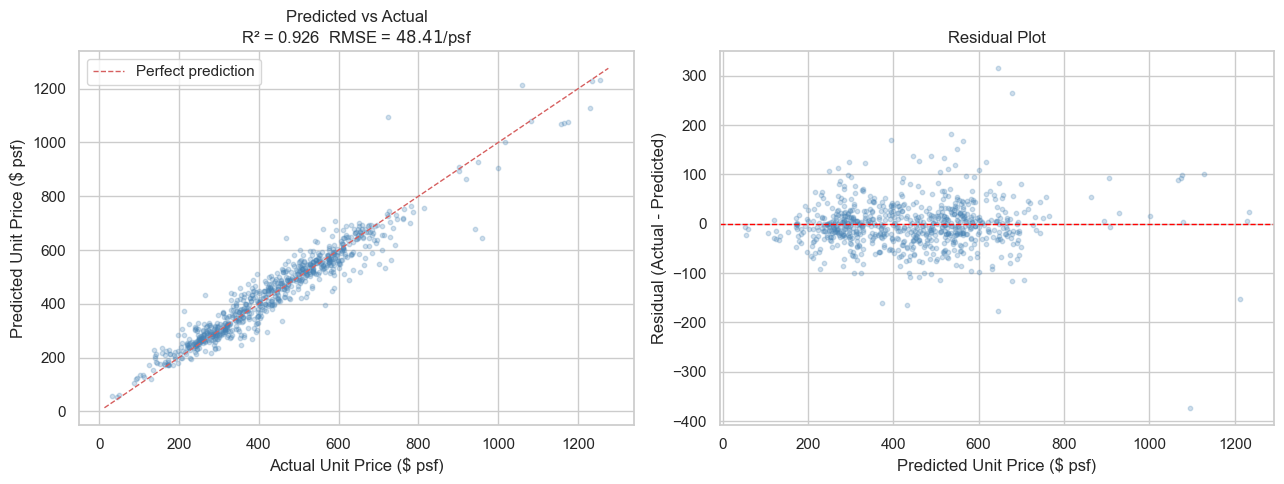

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predicted vs Actual
axes[0].scatter(y_test_raw, y_pred_raw, alpha=0.25, s=10, color="steelblue")
lims = [min(y_test_raw.min(), y_pred_raw.min()) - 20,
        max(y_test_raw.max(), y_pred_raw.max()) + 20]
axes[0].plot(lims, lims, "r--", linewidth=1, label="Perfect prediction")
axes[0].set_xlabel("Actual Unit Price ($ psf)")
axes[0].set_ylabel("Predicted Unit Price ($ psf)")
axes[0].set_title(f"Predicted vs Actual\nR² = {r2_raw:.3f}  RMSE = ${rmse_raw:.2f} $/psf")
axes[0].legend()

# Residuals
residuals = y_test_raw.values - y_pred_raw
axes[1].scatter(y_pred_raw, residuals, alpha=0.25, s=10, color="steelblue")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Predicted Unit Price ($ psf)")
axes[1].set_ylabel("Residual (Actual - Predicted)")
axes[1].set_title("Residual Plot")

plt.tight_layout()
plt.show()

## 5. Feature Importance

Random Forest provides **impurity-based feature importance** — the average reduction in MSE (impurity) each feature contributes across all trees and all splits.

Higher importance = feature is used more often and produces larger MSE reductions when split on.

In [7]:
importances = best_model.feature_importances_
feature_names = X_train.columns.tolist()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances,
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print("Feature Importances (impurity-based):")
print(importance_df.to_string(index=False))
print(f"\nTop 3 features account for {importance_df['Importance'].head(3).sum()*100:.1f}% of total importance")

Feature Importances (impurity-based):
                    Feature  Importance
      Remaining_Lease_Years    0.353273
      Planning_Area_Encoded    0.205409
                   Log_Area    0.182152
              dist_to_mrt_m    0.116022
      Lease_Remaining_Ratio    0.052845
Floor Level_Non-First Floor    0.016301
         SORA_3M_Compounded    0.011966
             10Y_Bond_Yield    0.010215
      Cement_Bulk_Per_Tonne    0.009452
        Type of Sale_Resale    0.008283
              CPI_All_Items    0.008222
        GDP_YoY_Growth_Rate    0.005579
        Region_North Region    0.005282
         Region_West Region    0.004776
         Region_East Region    0.004669
          Unemployment_Rate    0.003159
        Floor Level_Unknown    0.001833
   Region_North-East Region    0.000561

Top 3 features account for 74.1% of total importance


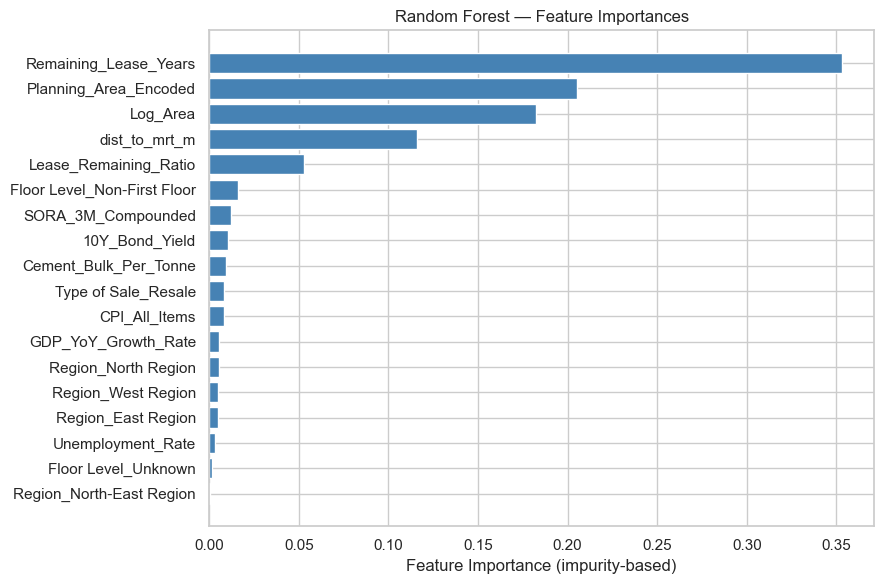

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(
    importance_df["Feature"][::-1],
    importance_df["Importance"][::-1],
    color="steelblue"
)
ax.set_xlabel("Feature Importance (impurity-based)")
ax.set_title("Random Forest — Feature Importances")
plt.tight_layout()
plt.show()

## 6. Comparison with Ridge Regression

In [9]:
ridge_model = joblib.load("../models/ridge_pipeline.pkl")
y_pred_ridge = np.exp(ridge_model.predict(X_test))
rmse_ridge = np.sqrt(mean_squared_error(y_test_raw, y_pred_ridge))
mae_ridge  = np.mean(np.abs(y_test_raw.values - y_pred_ridge))
r2_ridge   = r2_score(y_test_raw, y_pred_ridge)

comparison = pd.DataFrame({
    "Model":         ["Ridge Regression", "Random Forest"],
    "RMSE ($/psf)":  [f"${rmse_ridge:.2f}", f"${rmse_raw:.2f}"],
    "MAE ($/psf)":   [f"${mae_ridge:.2f}", f"${mae_raw:.2f}"],
    "R²":            [f"{r2_ridge:.4f}", f"{r2_raw:.4f}"],
    "RMSE % of mean":[f"{rmse_ridge/y_test_raw.mean()*100:.1f}%", f"{rmse_raw/y_test_raw.mean()*100:.1f}%"],
})

print(comparison.to_string(index=False))

           Model RMSE ($/psf) MAE ($/psf)     R² RMSE % of mean
Ridge Regression       $82.60      $61.04 0.7845          18.8%
   Random Forest       $48.41      $33.23 0.9260          11.0%


## 7. Save Model

In [10]:
joblib.dump(best_model, "../models/random_forest.pkl")

print("Saved: models/random_forest.pkl")
print()
print("=" * 50)
print("RANDOM FOREST SUMMARY")
print("=" * 50)
for k, v in grid_search.best_params_.items():
    print(f"{k+':':25s} {v}")
print()
print(f"CV RMSE:             ${-grid_search.best_score_:.2f} $/psf")
print(f"Test RMSE:           ${rmse_raw:.2f} $/psf")
print(f"Test MAE:            ${mae_raw:.2f} $/psf")
print(f"Test R²:             {r2_raw:.4f}")
print(f"RMSE as % of mean:   {rmse_raw / y_test_raw.mean() * 100:.1f}%")

Saved: models/random_forest.pkl

RANDOM FOREST SUMMARY
max_depth:                20
max_features:             0.5
min_samples_leaf:         1
n_estimators:             200

CV RMSE:             $56.71 $/psf
Test RMSE:           $48.41 $/psf
Test MAE:            $33.23 $/psf
Test R²:             0.9260
RMSE as % of mean:   11.0%
